In [9]:
 cd ~/work/tutorials/sources/OpenDrift


/home/jovyan/work/tutorials/sources/OpenDrift


In [4]:
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader  
from datetime import timedelta, datetime
import xarray as xr
import numpy as np
import glob

In [ ]:
#test case where seafloor_action is triggered (does not trigger here though)
o=OpenBerg(loglevel=50
          )
o.set_config('general:use_auto_landmask', False)
mapping_dict = {}
mapping_dict['standard_name_mapping']={'sea_floor_depth_below_sea_level':'sea_floor_depth_below_sea_level',
            'land_binary_mask':'land_binary_mask'}
with xr.open_mfdataset('./openberg_july2026/input/gebco_2026_n85.0_s35.0_w-80.0_e0.0.nc') as ds_env:
    ds_env['sea_floor_depth_below_sea_level'] = (('lat','lon'),-ds_env.elevation.data)#np.where(-ds_env.elevation.data>0,-ds_env.elevation.data,1))
    ds_env.sea_floor_depth_below_sea_level.attrs['standard_name']='sea_floor_depth_below_sea_level'
    ds_env['land_binary_mask'] = (('lat','lon'),np.where(-ds_env.elevation.data>0,0,1))
reader_env = Reader(ds_env,name="gebco",**mapping_dict)
o.add_reader(reader_env)
o.add_readers_from_list(['cmems_mod_arc_phy_my_topaz4_P1D-m',])
o.seed_elements(            lon=-56,
            lat=72.470032,
            time=datetime(2021,9,26,14),
            number=1,
            length=300,
            width=200,draft=100,sail=10)

oi = o.run(duration=timedelta(days=2))

In [ ]:
#Test case where too large size (and unrealistic shape) has inifit forcing
o=OpenBerg(loglevel=50)
o.add_readers_from_list(['cmems_mod_arc_phy_my_topaz4_P1D-m','cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H'])
o.seed_elements(
            lon=-36.21637488,
            lat=65.47819086,
            time=datetime(2024,7,6,14),
            number=1,
            length=40000, width=4.74957642e-07,draft=2.37842191e-07,sail=3.35621759e-08)
oi = o.run(duration=timedelta(days=4))

In [40]:
#Test which sizez are calculated wrongly with emp relations of iceberg shape
path_res = './openberg_july2026/results'

ib = 'iceberg2021w'
file_l = glob.glob("%s/%s/*.nc"%(path_res,ib))

test = xr.open_dataset(file_l[0])

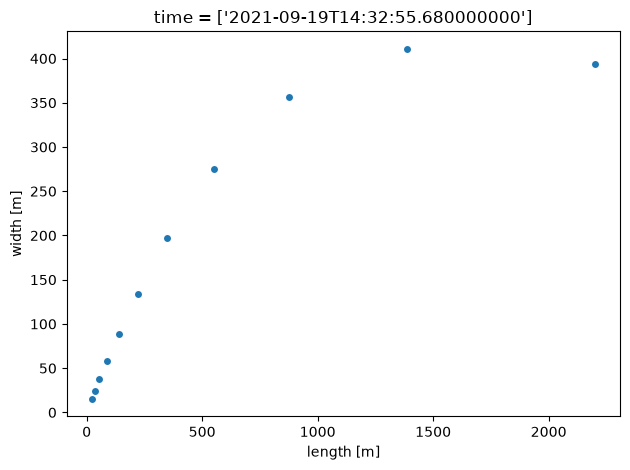

In [41]:
test.isel(time=[0]).plot.scatter(x='length',y='width')

np.int64(1600)

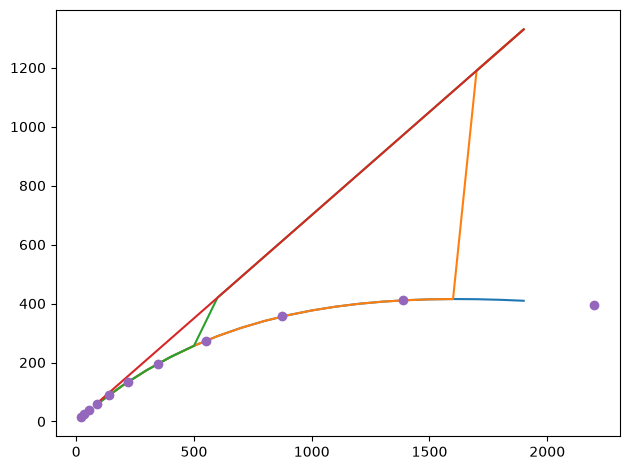

In [42]:
# test alternative shape calculations
import matplotlib.pyplot as plt
length= np.arange(100,2000,100)
width = 0.7 * length * np.exp(-0.00062 * length)
width2 = width.copy()
width2[length>1600]=0.7*length[length>1600]
width3 = width.copy()
width3[width<0.5*length]=0.7*length[width<0.5*length]
plt.plot(length,width)
plt.plot(length,width2)
plt.plot(length,width3)
plt.plot(length,length*0.7)
plt.plot(test.isel(time=[0]).length,test.isel(time=[0]).width,'o')
length[width.argmax()]

In [43]:
def calc_iceberg_size(iceberg_in):
    """
    Estimate missing iceberg properties (width, draft, sail)
    using empirical relationships based on length.
    
    Parameters
    ----------
    iceberg : dict
        Dictionary containing iceberg properties. Must include 'length'.
    
    Returns
    -------
    dict
        Updated iceberg dictionary with estimated values filled in.
    """
    iceberg_out = iceberg_in.copy()

    if 'length' not in iceberg_out:
        raise ValueError("Input must contain 'length'.")

    lengths = np.array(iceberg_out['length'])

    # --- Estimate width ---
    if 'width' not in iceberg_out:
        iceberg_out['width'] = 0.7 * lengths * np.exp(-0.00062 * lengths) 
        iceberg_out['width'][lengths>1600] = 0.8 * lengths[lengths>1600]

    # --- Estimate height ---
    height = 0.4 * lengths * np.exp(-0.00062 * lengths)

    # Physical constants (kg/m³)
    rho_i = 900   # ice density
    rho_w = 1027  # seawater density

    # Fraction below and above water
    frac_draft = rho_i / rho_w
    frac_sail = 1 - frac_draft

    # --- Handle draft and sail ---
    has_draft = 'draft' in iceberg_out
    has_sail = 'sail' in iceberg_out

    if not has_draft and not has_sail:
        # Compute both directly
        iceberg_out['draft'] = height * frac_draft
        iceberg_out['sail'] = height * frac_sail

    elif has_draft and not has_sail:
        # Compute sail from draft
        iceberg_out['sail'] = iceberg_out['draft'] * (frac_sail / frac_draft)

    elif has_sail and not has_draft:
        # Compute draft from sail
        iceberg_out['draft'] = iceberg_out['sail'] * (frac_draft / frac_sail)

    # If both exist, leave as is

    return iceberg_out